In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = yf.download("AAPL", start="2020-01-01", end="2025-12-01")


[*********************100%***********************]  1 of 1 completed


In [3]:
rango_completo = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(rango_completo)


In [4]:
print("Valores nulos generados:", df['Close'].isna().sum())


Valores nulos generados: Ticker
AAPL    672
dtype: int64


In [5]:
df['Close'] = df['Close'].ffill()
print("Ejemplo sábado:", df['Close'].iloc[5])


Ejemplo sábado: Ticker
AAPL    71.995346
Name: 2020-01-07 00:00:00, dtype: float64


In [6]:
mensual = df['Close'].resample('M').mean()
ultimo_anio = mensual.last('12M')


C:\Users\57316\AppData\Local\Temp\ipykernel_15296\1059884478.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mensual = df['Close'].resample('M').mean()
C:\Users\57316\AppData\Local\Temp\ipykernel_15296\1059884478.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  ultimo_anio = mensual.last('12M')
C:\Users\57316\AppData\Local\Temp\ipykernel_15296\1059884478.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ultimo_anio = mensual.last('12M')


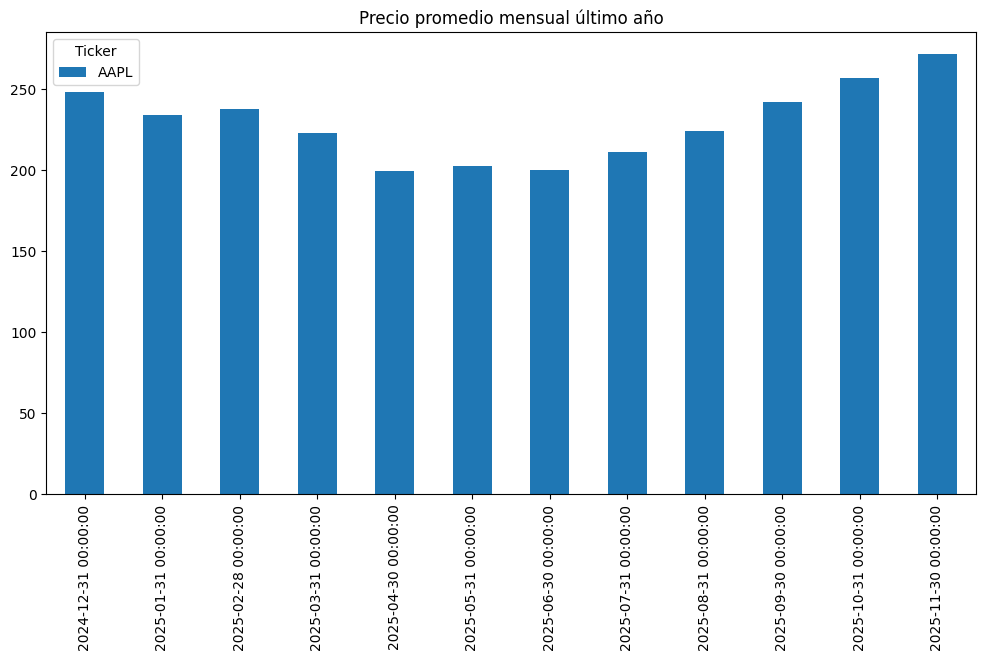

In [7]:
ultimo_anio.plot(kind='bar', figsize=(12,6))
plt.title("Precio promedio mensual último año")
plt.show()


[*********************100%***********************]  1 of 1 completed


Valores nulos generados: Ticker
AAPL    672
dtype: int64
Ejemplo sábado: Ticker
AAPL    71.995346
Name: 2020-01-07 00:00:00, dtype: float64


C:\Users\57316\AppData\Local\Temp\ipykernel_15296\2969746549.py:121: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mensual = df['Close'].resample('M').mean()
C:\Users\57316\AppData\Local\Temp\ipykernel_15296\2969746549.py:138: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  ultimo_anio = mensual.last('12M')
C:\Users\57316\AppData\Local\Temp\ipykernel_15296\2969746549.py:138: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ultimo_anio = mensual.last('12M')


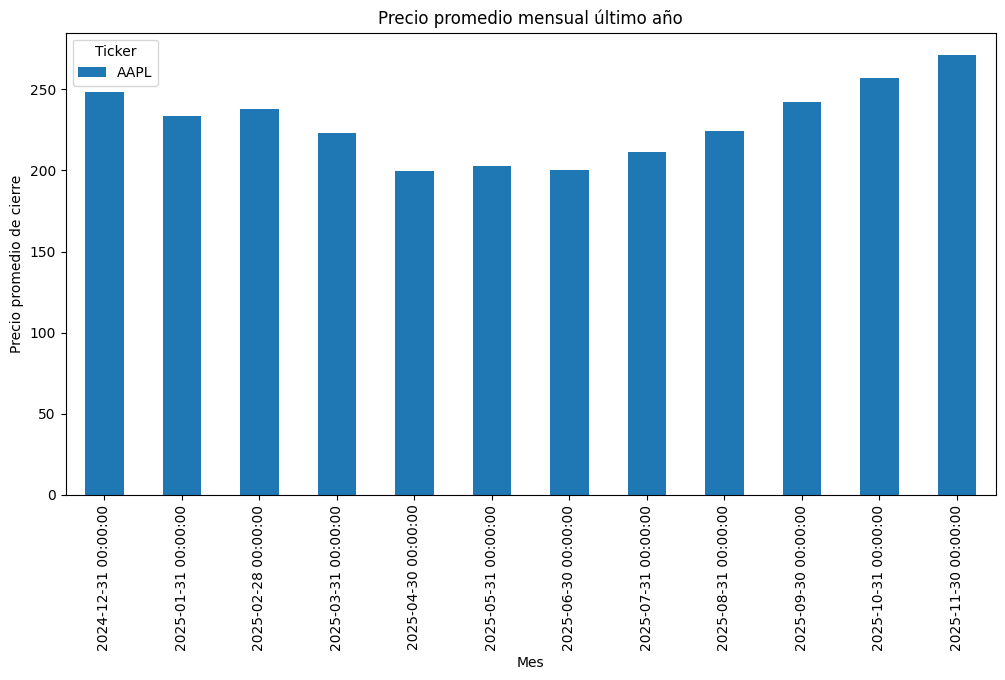

In [8]:
# ------------------------------------------------------------
# EJERCICIO 4 – ANÁLISIS DE SERIES TEMPORALES
#
# Descripción:
# En este ejercicio se trabaja con una serie temporal de
# precios financieros que solo contiene datos de días
# laborables. El objetivo es:
#
# 1. Generar un rango completo de fechas que incluya todos
#    los días naturales (incluidos fines de semana).
# 2. Detectar los valores nulos (NaN) generados.
# 3. Rellenar los valores faltantes usando Forward Fill.
# 4. Cambiar la granularidad de los datos a frecuencia mensual.
# 5. Calcular el precio promedio de cierre mensual.
# 6. Visualizar la evolución del precio promedio mensual
#    durante el último año.
#
# Para el análisis se utilizan datos reales de la acción
# Apple Inc. (AAPL) desde 2020 hasta diciembre de 2025.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------
# pandas: manejo de series temporales y DataFrames
# yfinance: descarga de datos financieros reales
# matplotlib: visualización de datos
# ------------------------------------------------------------

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 2. DESCARGA DE DATOS FINANCIEROS
# ------------------------------------------------------------
# Se descargan los precios históricos diarios de AAPL
# para el período comprendido entre 2020-01-01 y 2025-12-01.
# ------------------------------------------------------------

df = yf.download("AAPL", start="2020-01-01", end="2025-12-01")


# ------------------------------------------------------------
# VERIFICACIÓN 1:
# El índice del DataFrame debe ser de tipo fecha
# y contener solo días laborables.
# ------------------------------------------------------------
# print(df.head())
# print(df.index)


# ------------------------------------------------------------
# 3. GENERACIÓN DE HUECOS EN LA SERIE TEMPORAL
# ------------------------------------------------------------
# Se crea un rango completo de fechas que incluye todos
# los días naturales (lunes a domingo).
# Posteriormente, se reindexa el DataFrame original.
# Esto genera valores NaN en los días no laborables.
# ------------------------------------------------------------

rango_completo = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='D'
)

df = df.reindex(rango_completo)


# ------------------------------------------------------------
# 4. DETECCIÓN DE VALORES NULOS
# ------------------------------------------------------------
# Se cuenta el número de valores nulos generados en la
# columna 'Close' debido a la inclusión de fines de semana.
# ------------------------------------------------------------

print("Valores nulos generados:", df['Close'].isna().sum())


# ------------------------------------------------------------
# VERIFICACIÓN 2:
# Al mostrar filas correspondientes a sábados o domingos,
# se deben observar valores NaN antes del relleno.
# ------------------------------------------------------------
# print(df.loc['2021-01-02':'2021-01-03'])


# ------------------------------------------------------------
# 5. LIMPIEZA DE DATOS – FORWARD FILL
# ------------------------------------------------------------
# Se rellenan los valores nulos utilizando el método
# Forward Fill (ffill).
#
# Lógica:
# El precio del sábado y domingo se asume igual al
# precio de cierre del viernes anterior.
# ------------------------------------------------------------

df['Close'] = df['Close'].ffill()


# ------------------------------------------------------------
# VERIFICACIÓN 3:
# Se muestra un ejemplo de un día no laborable para
# confirmar que el valor fue correctamente rellenado.
# ------------------------------------------------------------

print("Ejemplo sábado:", df['Close'].iloc[5])


# ------------------------------------------------------------
# 6. CAMBIO DE GRANULARIDAD – REMUESTREO MENSUAL
# ------------------------------------------------------------
# Se transforma la serie diaria a una serie mensual
# utilizando el promedio del precio de cierre.
# ------------------------------------------------------------

mensual = df['Close'].resample('M').mean()


# ------------------------------------------------------------
# VERIFICACIÓN 4:
# El índice del DataFrame ahora debe tener frecuencia mensual.
# ------------------------------------------------------------
# print(mensual.head())


# ------------------------------------------------------------
# 7. SELECCIÓN DEL ÚLTIMO AÑO
# ------------------------------------------------------------
# Se extraen los últimos 12 meses de la serie mensual
# para su análisis y visualización.
# ------------------------------------------------------------

ultimo_anio = mensual.last('12M')


# ------------------------------------------------------------
# 8. VISUALIZACIÓN DE RESULTADOS
# ------------------------------------------------------------
# Se genera un gráfico de barras que muestra la evolución
# del precio promedio mensual de cierre durante el último año.
# ------------------------------------------------------------

ultimo_anio.plot(kind='bar', figsize=(12, 6))
plt.title("Precio promedio mensual último año")
plt.xlabel("Mes")
plt.ylabel("Precio promedio de cierre")
plt.show()


# ------------------------------------------------------------
# VALIDACIÓN FINAL DEL EJERCICIO
# ------------------------------------------------------------
# El ejercicio se considera correctamente implementado si:
# - Se generan valores NaN al incluir días no laborables.
# - Los valores NaN son correctamente rellenados con ffill.
# - El remuestreo mensual se realiza sin errores.
# - El gráfico refleja correctamente la evolución mensual.
# ------------------------------------------------------------
